# **Koala Dataset Analysis Workflow**

## A Complete Pipeline from Data Cleaning to Statistical Analysis

### Introduction:
Australian Koalas are iconic species native to Australia. They inhabit in eucalyptus forests and woodlands across eastern and southeastern Australia. Their habitat is defined by the presence of select eucalyptus trees, which form the majority of their diet and provide shelter.

This analysis examines koala morphological characteristics (head length, skull width, total length) and demographics (age, gender, habitat) to identify biological trends and conservation indicators.

One thing that I have done when deep dive into the data is to conver from xlsx to csv online via this page: https://www.freeconvert.com/csv-converter


# 0. Import All Dependencies

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Import all the libraries we need
# pandas for data, numpy for math, matplotlib/seaborn for plots, scipy for stats

# 1. Data Cleaning & Standardization

In [26]:
# Set up file names for input and output
input_file_name = "koalas_dataset.csv"
output_file_name = "fully_cleaned_koalas_dataset.csv"

print(f"Starting data cleaning and standardization for: {input_file_name}")

# Try to load the data file, show error if it fails
try:
    df = pd.read_csv(input_file_name)
    print(f"\nSuccessfully loaded {input_file_name}. Original shape: {df.shape}")
except FileNotFoundError as e:
    raise FileNotFoundError(f"Error: The file '{input_file_name}' was not found.") from e
except Exception as e:
    raise Exception(f"Error loading CSV file: {e}") from e

Starting data cleaning and standardization for: koalas_dataset.csv

Successfully loaded koalas_dataset.csv. Original shape: (169, 14)


## =====================
## Initial Cleaning
## =====================

In [4]:
# Start cleaning the data
# Make a copy of original data to clean
print("\n--- Performing Initial Cleaning ---")
df_cleaned = df.copy()


--- Performing Initial Cleaning ---


In [5]:
# Remove rows with missing values
print(f"Shape before dropping NA: {df_cleaned.shape}")
print("NA values before:\n", df_cleaned.isnull().sum())
df_cleaned.dropna(inplace=True)
print(f"\nShape after dropping NA: {df_cleaned.shape}")

Shape before dropping NA: (169, 14)
NA values before:
 koala_id                0
region                  2
habitat                 7
gender                  9
age_in_years           10
Paw Size               11
total_length           10
head_length            13
ear_size               12
foot_length            15
skull_width            11
eye_diameter           10
chest_circumference     6
belly_circumference     6
dtype: int64

Shape after dropping NA: (139, 14)


In [6]:
# Remove duplicates rows
print(f"\nDuplicates before: {df_cleaned.duplicated().sum()}")
df_cleaned.drop_duplicates(inplace=True)
print(f"Duplicates after: {df_cleaned.duplicated().sum()}")


Duplicates before: 0
Duplicates after: 0


In [7]:
# Standardize text columns (Clean up text columns - make everything lowercase and remove extra spaces)
text_cols = df_cleaned.select_dtypes(include=['object']).columns
for col in text_cols:
    df_cleaned[col] = df_cleaned[col].str.lower().str.strip()

## =====================
## Categorical Standardization
## =====================

In [8]:
# Fix inconsistent category names
# Standardize habitat and gender values
print("\n--- Categorical Data Standardization ---")

habitat_map = {'vic': 'victoria', 'qld': 'queensland',
               'queenstown': 'queensland', 'q': 'queensland'}
gender_map = {'f': 'female', 'm': 'male'}

df_cleaned['habitat'] = df_cleaned['habitat'].replace(habitat_map)
df_cleaned['gender'] = df_cleaned['gender'].replace(gender_map)


--- Categorical Data Standardization ---


## =====================
## Final Cleaning Output
## =====================

In [9]:
# Save the cleaned data to new file
try:
    df_cleaned.to_csv(output_file_name, index=False)
    print(f"\nSaved cleaned data to {output_file_name}")
except Exception as e:
    print(f"Error saving file: {e}")

print("\n=== Cleaning Summary ===")
print(f"Original shape: {df.shape}")
print(f"Cleaned shape: {df_cleaned.shape}")
print("First 5 rows of cleaned data:")
display(df_cleaned.head())


Saved cleaned data to fully_cleaned_koalas_dataset.csv

=== Cleaning Summary ===
Original shape: (169, 14)
Cleaned shape: (139, 14)
First 5 rows of cleaned data:


,koala_id,region,habitat,gender,age_in_years,Paw Size,total_length,head_length,ear_size,foot_length,skull_width,eye_diameter,chest_circumference,belly_circumference
2,3,1.0,victoria,female,6.0,19.0,83.5,19.0,16.9,25.4,15.0,2.5,65.0,59.0
3,4,1.0,victoria,female,6.0,18.0,80.0,18.2,17.2,26.1,12.1,2.2,63.0,59.0
4,5,1.0,victoria,female,2.0,16.0,73.5,16.5,18.2,21.0,11.3,2.1,63.5,58.0
5,6,1.0,victoria,female,1.0,15.5,78.5,18.1,18.6,23.2,9.8,1.2,65.0,57.0
6,7,1.0,victoria,male,2.0,16.0,77.5,20.3,17.0,21.5,13.2,1.2,65.0,59.5


#2. Exploratory Data Analysis (EDA)

## =====================
## Data Inspection
## =====================

In [10]:
# Make copy of cleaned data
df = df_cleaned.copy()

# Show basic info about the data
print("=== Dataset Overview ===")
print("First 5 rows:")
display(df.head())
print("\nData types:")
print(df.dtypes)
print("\nDescriptive stats:")
display(df.describe())

=== Dataset Overview ===
First 5 rows:


,koala_id,region,habitat,gender,age_in_years,Paw Size,total_length,head_length,ear_size,foot_length,skull_width,eye_diameter,chest_circumference,belly_circumference
2,3,1.0,victoria,female,6.0,19.0,83.5,19.0,16.9,25.4,15.0,2.5,65.0,59.0
3,4,1.0,victoria,female,6.0,18.0,80.0,18.2,17.2,26.1,12.1,2.2,63.0,59.0
4,5,1.0,victoria,female,2.0,16.0,73.5,16.5,18.2,21.0,11.3,2.1,63.5,58.0
5,6,1.0,victoria,female,1.0,15.5,78.5,18.1,18.6,23.2,9.8,1.2,65.0,57.0
6,7,1.0,victoria,male,2.0,16.0,77.5,20.3,17.0,21.5,13.2,1.2,65.0,59.5



Data types:
koala_id                 int64
region                 float64
habitat                 object
gender                  object
age_in_years           float64
Paw Size               float64
total_length           float64
head_length            float64
ear_size               float64
foot_length            float64
skull_width            float64
eye_diameter           float64
chest_circumference    float64
belly_circumference    float64
dtype: object

Descriptive stats:


,koala_id,region,age_in_years,Paw Size,total_length,head_length,ear_size,foot_length,skull_width,eye_diameter,chest_circumference,belly_circumference
count,139.000000,139.000000,139.000000,139.000000,139.000000,139.000000,139.000000,139.000000,139.000000,139.000000,139.000000,139.000000
mean,83.381295,3.136691,3.676259,16.866906,75.484892,18.517266,21.752518,19.074101,13.492086,4.869065,62.097122,57.571942
std,46.932328,2.233479,1.877463,1.973167,4.264870,8.562980,76.086581,4.400401,13.342088,33.812646,1.954072,2.699679
min,3.000000,1.000000,1.000000,12.000000,63.000000,7.500000,6.300000,10.300000,5.000000,0.500000,57.000000,50.000000
25%,42.500000,1.000000,2.000000,15.500000,73.000000,16.300000,10.200000,15.450000,10.300000,1.400000,60.500000,56.000000
50%,86.000000,2.000000,3.000000,17.000000,76.000000,17.900000,15.800000,19.800000,11.300000,1.900000,62.000000,57.000000
75%,123.500000,5.000000,5.000000,18.000000,78.250000,19.800000,17.700000,23.000000,13.100000,2.500000,63.000000,59.000000
max,168.000000,7.000000,9.000000,23.000000,84.500000,110.500000,900.800000,27.900000,120.600000,400.500000,67.000000,65.000000


## =====================
## Distribution Analysis
## =====================

In [11]:
# Plot distributions of numerical values
plt.figure(figsize=(15,10))
numerical_cols = ['age_in_years', 'Paw Size', 'total_length',
                 'head_length', 'ear_size', 'foot_length']

<Figure size 1500x1000 with 0 Axes>

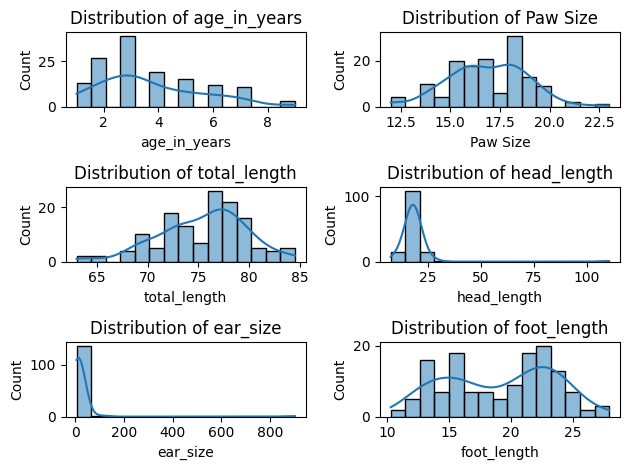

In [12]:
# Make histograms for each numerical column
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(3,2,i)
    sns.histplot(df[col], kde=True, bins=15)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

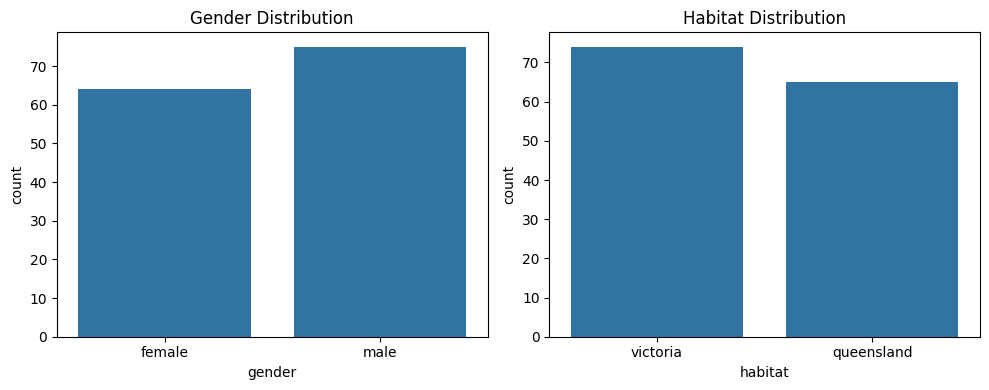

In [13]:
# Plot counts for categorical columns
plt.figure(figsize=(10,4))
plt.subplot(121)
sns.countplot(x='gender', data=df)
plt.title('Gender Distribution')
plt.subplot(122)
sns.countplot(x='habitat', data=df)
plt.title('Habitat Distribution')
plt.tight_layout()
plt.show()

## =====================
## Relationship Analysis
## =====================

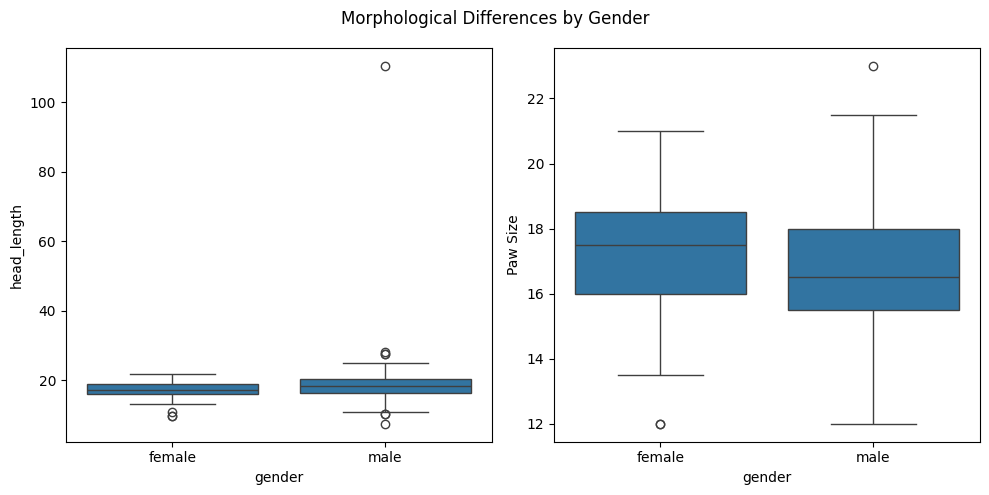

In [14]:
# Compare measurements between genders
plt.figure(figsize=(10,5))
plt.subplot(121)
sns.boxplot(x='gender', y='head_length', data=df)
plt.subplot(122)
sns.boxplot(x='gender', y='Paw Size', data=df)
plt.suptitle('Morphological Differences by Gender')
plt.tight_layout()
plt.show()

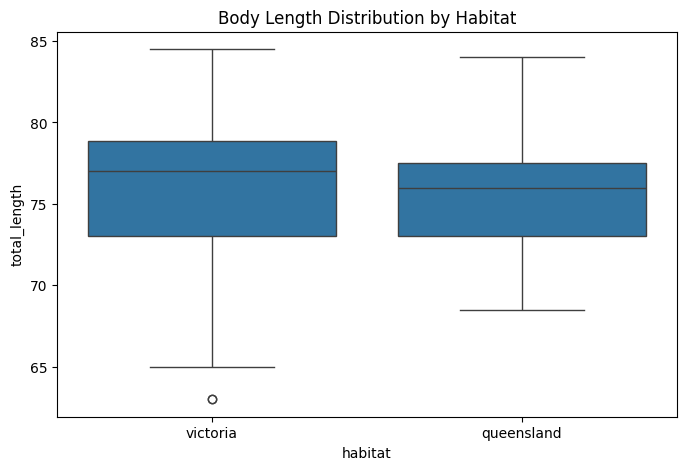

In [15]:
# Compare size between habitats
plt.figure(figsize=(8,5))
sns.boxplot(x='habitat', y='total_length', data=df)
plt.title('Body Length Distribution by Habitat')
plt.show()

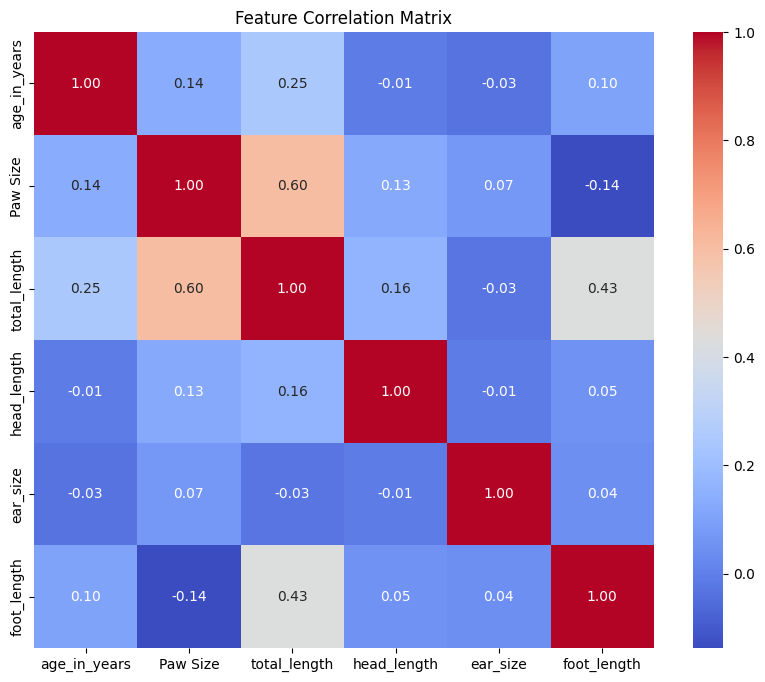

In [16]:
# Show correlation between all numerical features
corr_matrix = df[numerical_cols].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.show()

#3. Advanced Visualizations


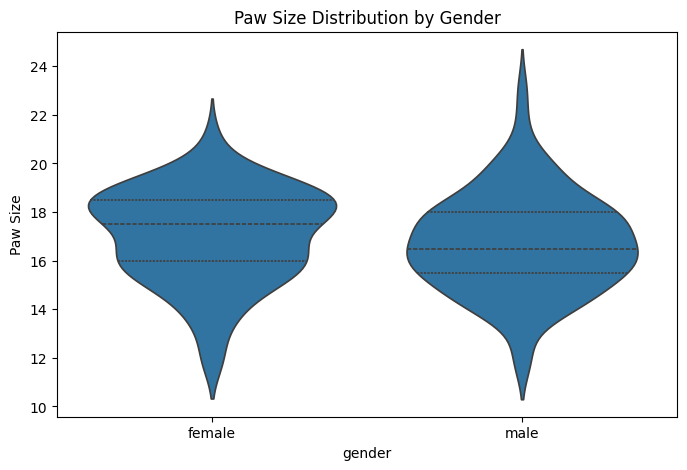

In [17]:
# Fancy paw size comparison plot
plt.figure(figsize=(8,5))
sns.violinplot(x='gender', y='Paw Size', data=df, inner='quartile')
plt.title('Paw Size Distribution by Gender')
plt.show()

<Figure size 900x500 with 0 Axes>

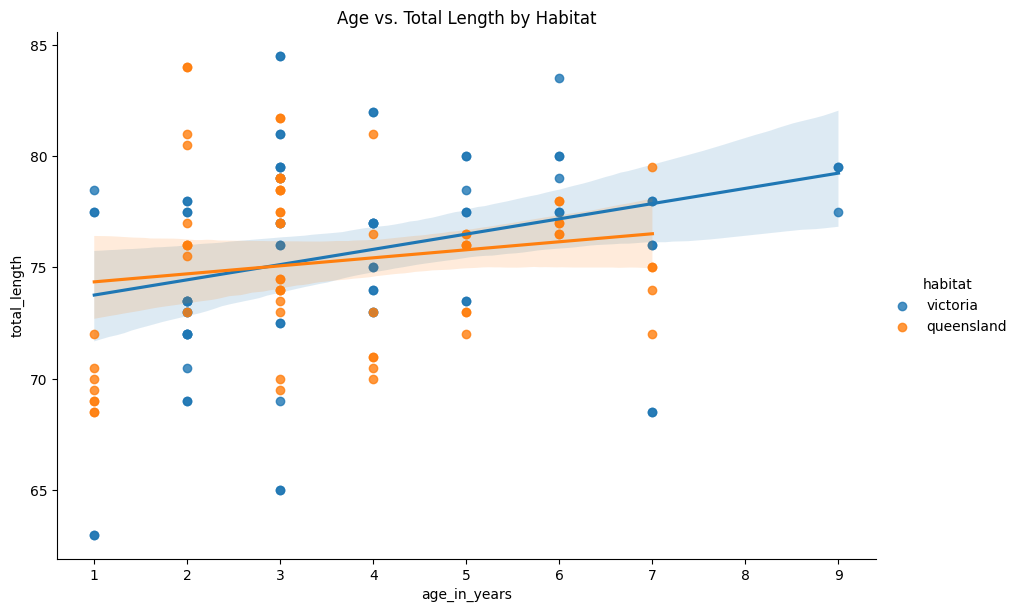

In [18]:
# Age vs size plot with trend lines
plt.figure(figsize=(9,5))
sns.lmplot(x='age_in_years', y='total_length', hue='habitat',
           data=df, height=6, aspect=1.5)
plt.title('Age vs. Total Length by Habitat')
plt.show()

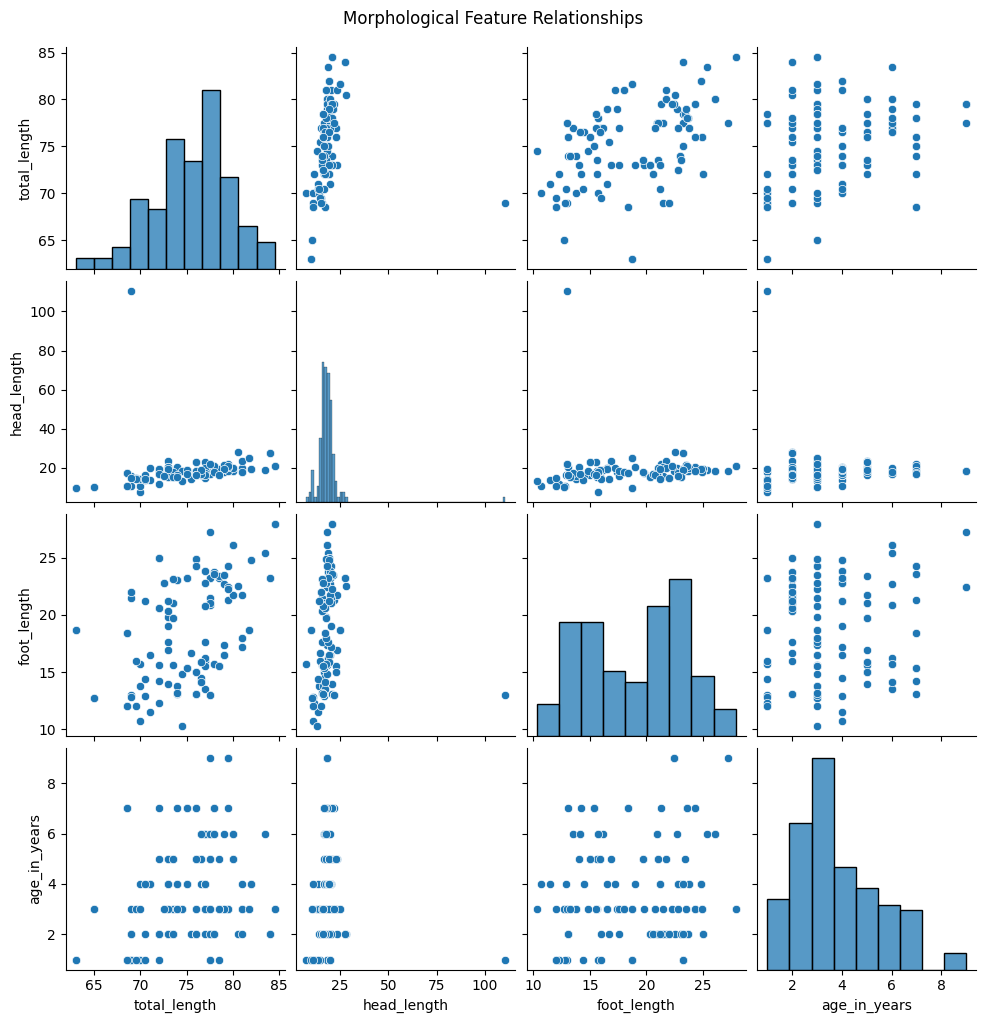

In [19]:
# Scatterplot matrix of key features
sns.pairplot(df[['total_length', 'head_length', 'foot_length', 'age_in_years']])
plt.suptitle('Morphological Feature Relationships', y=1.02)
plt.show()

#4. Statistical Analysis

In [20]:
# Q1: Head length different from 65cm?
_, p1 = stats.wilcoxon(df['head_length'] - 65)
print(f"Q1: Are head lengths different from 65cm? p = {p1:.4f}")

Q1: Are head lengths different from 65cm? p = 0.0000


### Question 1: Head length different from 65cm?
**Conclusion:** There is a highly statistically significant difference between the average head length of the koalas in the dataset and 65cm.

**Interpretation:** The p-value of 0.0000 (which is less than the typical alpha level of 0.05) strongly suggests that it's very unlikely this observed difference is due to random chance. The koalas on average, do not have a head length of 65cm. Further investigation into the actual mean or median head length would clarify whether they are typically larger or smaller.

In [21]:
# Q2: Head length by gender
male = df[df['gender'] == 'male']['head_length']
female = df[df['gender'] == 'female']['head_length']
_, p2 = stats.mannwhitneyu(male, female)
print(f"\nQ2: Head length gender difference? p = {p2:.4f}")


Q2: Head length gender difference? p = 0.0147


### Q2: Head length gender difference? (p = 0.0147)
**Conclusion:** There is a statistically significant difference in head length between male and female koalas.

**Interpretation:** With a p-value of 0.0147 (which is less than 0.05), we can conclude that gender has a significant association with head length.

In [22]:
# Q3: Paw size gender difference
_, p3 = stats.ttest_ind(male, df['Paw Size'][df['gender'] == 'female'])
print(f"\nQ3: Paw size gender difference? p = {p3:.4f}")


Q3: Paw size gender difference? p = 0.0738


### Q3: Paw size gender difference?
**Conclusion:** There is no statistically significant difference in paw size between male and female koalas at the 5% significance level.

**Interpretation:** The p-value of 0.0738 is greater than 0.05. This means that while there might be some observed difference in average paw sizes between genders in your sample, this difference is not large enough to be considered statistically significant. There's a reasonable probability that this observed difference could be due to random sampling variability.

In [23]:
# Q4: Habitat size difference
vic = df[df['habitat'] == 'victoria']['total_length']
qld = df[df['habitat'] == 'queensland']['total_length']
_, p4 = stats.ttest_ind(vic, qld, equal_var=False)
print(f"\nQ4: Habitat size difference? p = {p4:.4f}")


Q4: Habitat size difference? p = 0.5708


### Q4: Habitat size difference?

**Conclusion:** There is no statistically significant difference in the total length (size) of koalas based on their habitat (Victoria vs. Queensland).

**Interpretation:** The high p-value of 0.5708 (much greater than 0.05) indicates that the observed differences in average total length between koalas from Victoria and Queensland are likely due to random chance. The data does not provide sufficient evidence to claim that koalas from one habitat are generally larger or smaller than those from the other.

### Question 5:
**Visualization:** Heatmap of Pearson correlations.  
**Total Length and Foot Length**: These variables show a clear positive correlation, meaning as total length increases, foot length also tends to increase.
1.  **Total Length and Foot Length:**
    * **Correlation Coefficient (r):** 0.43
    * **p-value:** 0.0000
    * **Interpretation:** This indicates a statistically significant (since p < 0.05) moderate positive linear correlation. As total length increases, foot length tends to increase, and this relationship is unlikely due to random chance.

**Total Length and Head Length**: These also show a positive correlation, indicating that koalas with greater total length tend to have greater head length.
2.  **Total Length and Head Length:**
    * **Correlation Coefficient (r):** 0.16
    * **p-value:** 0.0565
    * **Interpretation:** This indicates a weak positive linear correlation. The p-value is slightly above the common 0.05 threshold for statistical significance, suggesting that the evidence for this correlation is marginal. While there's a slight tendency for head length to increase with total length, the relationship isn't strong, and we can't be as confident that it's not due to random chance compared to the total length and foot length correlation.

In [24]:
# Q6-Q7: Check correlations between body length and other features
r_head, p_head = stats.pearsonr(df['total_length'], df['head_length'])
r_foot, p_foot = stats.pearsonr(df['total_length'], df['foot_length'])
print(f"\nQ6: Head length correlation (r={r_head:.2f}, p={p_head:.4f})")
print(f"Q7: Foot length correlation (r={r_foot:.2f}, p={p_foot:.4f})")



Q6: Head length correlation (r=0.16, p=0.0565)
Q7: Foot length correlation (r=0.43, p=0.0000)


### Q6: Head length correlation (with total body length) (r=0.16, p=0.0565)

**Conclusion:** There is a very weak positive correlation between total body length and head length, and this correlation is borderline not statistically significant at the 5% level.

**Interpretation:** The Pearson correlation coefficient (r) of 0.16 suggests that as total body length increases, head length tends to increase slightly, but the relationship is very weak. The p-value of 0.0565 is just above the 0.05 threshold, meaning we cannot confidently reject the null hypothesis that there is no linear correlation. More data might be needed to clarify this relationship.

### Q7: Foot length correlation (with total body length) (r=0.43, p=0.0000)
**Conclusion:** There is a statistically significant, moderate positive correlation between total body length and foot length.

**Interpretation:** The r-value of 0.43 indicates a moderate positive linear relationship: as the total body length of a koala increases, its foot length also tends to increase. The p-value of 0.0000 (highly significant) confirms that this observed correlation is very unlikely to be due to random chance.